<p>
<h1><b><center>Mecánica de Medios Continuos</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 3 - Modelando el interior solar</center></b><h2>


## Enunciado

**Objetivo**: El objetivo de esta tarea es estudiar el interior de estrellas reales usando para ello modelos politrópicos de cuerpos autogravitantes.

Para ello nos apoyaremos, como fuente de información y para validar nuestros modelos, de los resultados de simulaciones realistas del interior estelar disponibles en el sitio web http://user.astro.wisc.edu/~townsend/static.php?ref=ez-web.

\

**Procedimiento**:

Para conseguir el objetivo:

1. Descargar los datos de evolución y estructura interior de una estrella con la masa, metalicidad (Z=0.02) del Sol usando el formulario http://user.astro.wisc.edu/~townsend/static.php?ref=ez-web#Submit_a_Calculation.

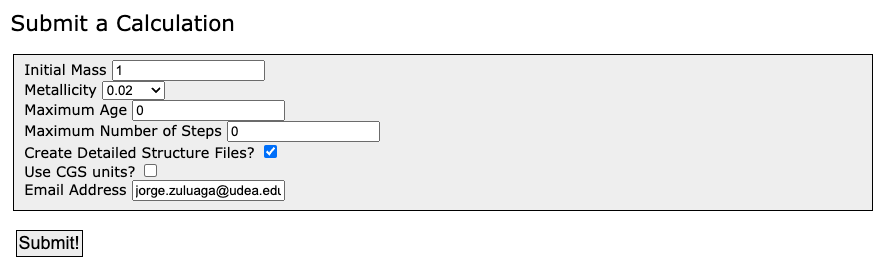

2. Los datos provistos en un archivo comprimido son:

   - *summary.txt*: Contienen datos sobre la evolución de la estrella. Las columnas del archivo se describen en http://user.astro.wisc.edu/~townsend/static.php?ref=ez-web. En particular nos interesa la primera columna *i* que indica el archivo con la estructura detallada en cada tiempo de simulación. En la segunda columna *t* está la edad de la estrella. Para cada edad nos dan las propiedades de la estrella, masa, luminosidad, radio, densidad central, presión central, etc.

   - *structure_NNNNN.txt*: archivos con datos de las propiedades interiores de la estrella. Las columnas del archivo se describen en http://user.astro.wisc.edu/~townsend/static.php?ref=ez-web. En particular nos interesan las columnas de radio (columna 2), temperatura (columna 6), densidad (columna 5), presión (columna 4), índice adiabático (columna 10).

   Hacer gráficos de las siguientes propiedades de la estrella como función del tiempo:

   - Temperatura central.
   - Fracción de Helio en el centro.
   - Radio de la estrella.

   Estos gráficos nos dan una idea de las distintas etapas por las que pasa la estrella.


3. Vamos a estudiar la estructura del Sol en 4 momentos de su vida. Para cada uno de estos momentos recuperar los datos de la estructura provistos por el modelo.

   - **Inicio**. En la fase de secuencia principal de edad 0. Este es el primer momento de la estrella.
   - **Tiempo presente**. En la fase actual, correspondiente a 4560 millones de años.
   - **Fin de la secuencia principal**. En la fase de final de la fusión del Hidrógeno en el centro, que corresponde a un tiempo cuando la fracción de Helio en el centro alcanza un valor $Y_c \approx 1$.
   - **Fusión del Helio (gigante roja)**. En la fase de fusión del Helio, cuando la temperatura del centro es 75 millones de grados.

4. Para cada etapa vamos a usar la solución a la ecuación de Lane-Emden para encontrar la temperatura, densidad y presión interior de la estrella y vamos a comparar la calidad de nuestro modelo con el modelo exacto.

   - Recuperar el valor del índice adiabático $\gamma$ y el calor específico $C_P$ del modelo realista para la estrella.

   - Usando las propiedades superficiales (masa, radio) calcular la temperatura y densidad central predicha por la ecuación de Lane-Emden (como lo hicimos en el ejemplo de clase).

   - Calcular la temperatura densidad y presión del interior de la estrella usando la solución de la ecuación de Lane-Emden en cada fase y comparar con el modelo realista de la estrella.

5. ¿Cómo podría mejorarse el ajuste entre las propiedades calculadas con el modelo politrópico y el model realista? Intentelo al menos con el interior del Sol en una de las etapas estudiadas.

**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos mínimos:
  - 3 Gráficos de temperatura central, fracción de Helio en el centro, radio como función del tiempo para la estrella.
  - Gráficos de temperatura, densidad y presión del interior de la estrella en cada fase, calculados con la ecuación de Lane-Emden, comparadas con las mismas propiedades obtenidas con el modelo realista. En total son 12 gráficos (4 etapas, 3 propiedades).
  - Gráficos de temperatura, densidad y presión mejorados (punto 5).

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.

### Punto 1 - Carga de los datos


In [ ]:
pip install gdown &> /dev/null

In [ ]:
# Importamos las librerías necesarias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gdown
from scipy.integrate import solve_ivp,quad

In [ ]:
files = 'https://drive.google.com/drive/folders/1lFX_5-hZZYLWBtrjm5CB47u5spbaGTE4?usp=drive_link'
gdown.download_folder(files)

Retrieving folder list


Processing file 18iDk-fH_CZAffH3u-TK3225Q2yr_orcq structure_00000.txt
Processing file 17kyxw4_navY7OqFnN0RfaGqKYtLvPhF1 structure_00065.txt
Processing file 11Q0oJx2yQxG8NH47MTzvGlXJRyaggl_S structure_00135.txt
Processing file 1ZiKuodOUkrBmbfsUBLw0Y8ZjFAcQtOoj structure_00454.txt
Processing file 1HZwkgjplAa0BzOd73PIs3kwlnk7bAevO summary.txt
Building directory structure completed


Retrieving folder list completed
Building directory structure
Downloading...
From: https://drive.google.com/uc?id=18iDk-fH_CZAffH3u-TK3225Q2yr_orcq
To: /content/datos_ezweb/structure_00000.txt
100%|██████████| 115k/115k [00:00<00:00, 65.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=17kyxw4_navY7OqFnN0RfaGqKYtLvPhF1
To: /content/datos_ezweb/structure_00065.txt
100%|██████████| 115k/115k [00:00<00:00, 45.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=11Q0oJx2yQxG8NH47MTzvGlXJRyaggl_S
To: /content/datos_ezweb/structure_00135.txt
100%|██████████| 115k/115k [00:00<00:00, 43.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ZiKuodOUkrBmbfsUBLw0Y8ZjFAcQtOoj
To: /content/datos_ezweb/structure_00454.txt
100%|██████████| 115k/115k [00:00<00:00, 29.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HZwkgjplAa0BzOd73PIs3kwlnk7bAevO
To: /content/datos_ezweb/summary.txt
100%|██████████| 418k/418k [00:00<00:00, 30.2MB/s]
Download completed


['/content/datos_ezweb/structure_00000.txt',
 '/content/datos_ezweb/structure_00065.txt',
 '/content/datos_ezweb/structure_00135.txt',
 '/content/datos_ezweb/structure_00454.txt',
 '/content/datos_ezweb/summary.txt']

In [ ]:
names_c = ['i', 't', 'M', 'log10L', 'log10R', 'log10Ts', 'log10Tc', 'log10ρc', 'log10Pc', 'PSIc', 'Xc', 'Yc', 'XCc', 'XNc', 'XOc', 'Tdyn', 'TKH', 'Tnuc', 'Lpp', 'LCNO', 'L3sig', 'LZ', 'Lv', 'MHe', 'MC', 'MO', 'RHe', 'RC', 'RO']
df = pd.read_csv('datos_ezweb/summary.txt', sep='\s+', header=None)
df.columns = names_c
df.head(5)

,i,t,M,log10L,log10R,log10Ts,log10Tc,log10ρc,log10Pc,PSIc,...,LCNO,L3sig,LZ,Lv,MHe,MC,MO,RHe,RC,RO
0,0,0.0,1.0,-0.154656,-0.052737,3.749394,7.126281,4.893762,16.150422,-1.724627,...,0.052255,2.635337e-34,0.0,1.622945e-08,0.0,0.0,0.0,0.0,0.0,0.0
1,1,50000.0,1.0,-0.149121,-0.047791,3.748305,7.127136,4.893501,16.151001,-1.728404,...,0.054086,2.864470e-34,0.0,1.675944e-08,0.0,0.0,0.0,0.0,0.0,0.0
2,2,100000.0,1.0,-0.149131,-0.047801,3.748307,7.127134,4.893502,16.150999,-1.728400,...,0.054018,2.858303e-34,0.0,1.676856e-08,0.0,0.0,0.0,0.0,0.0,0.0
3,3,160000.0,1.0,-0.149117,-0.047798,3.748309,7.127135,4.893507,16.151003,-1.728391,...,0.053941,2.851385e-34,0.0,1.676853e-08,0.0,0.0,0.0,0.0,0.0,0.0
4,4,232000.0,1.0,-0.149109,-0.047796,3.748310,7.127134,4.893516,16.151008,-1.728374,...,0.053848,2.842977e-34,0.0,1.676847e-08,0.0,0.0,0.0,0.0,0.0,0.0


### Punto 2

   Hacer gráficos de las siguientes propiedades de la estrella como función del tiempo:

   - Temperatura central.
   - Fracción de Helio en el centro.
   - Radio de la estrella.

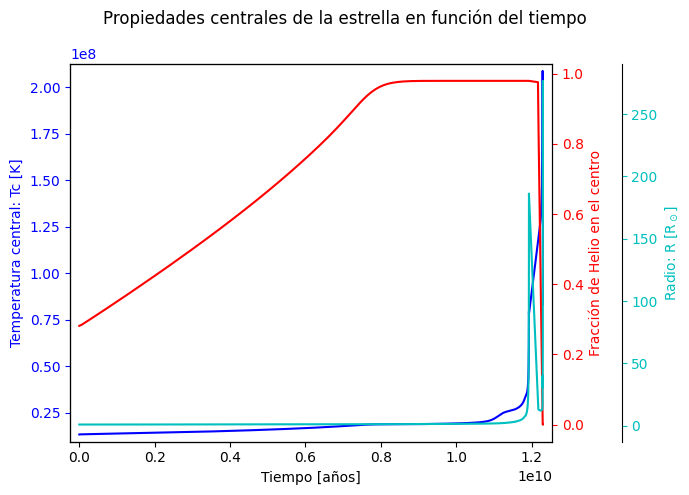

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
fig.suptitle('Propiedades centrales de la estrella en función del tiempo')

ax.plot(df.t, 10**df.log10Tc, c='b')
ax.set_xlabel("Tiempo [años]")
ax.set_ylabel("Temperatura central: Tc [K]")

# Decoración tomada de la fuente: https://stackoverflow.com/questions/4761623/how-to-change-the-color-of-the-axis-ticks-and-labels
ax.yaxis.label.set_color('b')
ax.tick_params(axis='y', colors='b')

axH = ax.twinx()   # Compartimos el gráfico
axH.plot(df.t, df.Yc, c='r')
axH.set_ylabel("Fracción de Helio en el centro")
axH.yaxis.label.set_color('r')
axH.tick_params(axis='y', colors='r')

axR = ax.twinx()
axR.plot(df.t, 10**df.log10R, c='c')
axR.set_ylabel("Radio: R [R$_\odot$]")
axR.yaxis.label.set_color('c')
axR.tick_params(axis='y', colors='c')

# Posicionamiento del eje de presión para evitar la superposición
axR.spines['right'].set_position(('outward', 50))

# Decoración
ax.margins(0.02,0.02)
# fig.legend(['Temperatura central', 'Fracción de Helio en el centro', 'Radio'])

fig.tight_layout()

### Punto 3

Vamos a estudiar la estructura del Sol en 4 momentos de su vida. Para cada uno de estos momentos recuperar los datos de la estructura provistos por el modelo.

   - **Inicio**. En la fase de secuencia principal de edad 0. Este es el primer momento de la estrella.
   - **Tiempo presente**. En la fase actual, correspondiente a 4560 millones de años.
   - **Fin de la secuencia principal**. En la fase de final de la fusión del Hidrógeno en el centro, que corresponde a un tiempo cuando la fracción de Helio en el centro alcanza un valor $Y_c \approx 1$.
   - **Fusión del Helio (gigante roja)**. En la fase de fusión del Helio, cuando la temperatura del centro es 75 millones de grados.

In [ ]:
# Determinamos el número de paso (i) de cada etapa del Sol utilizando una máscara para cada una
#
inicio = '00000'

actual = f'{df.i[abs(df.t*1e-6 - 4560) <= 1].to_numpy()[0]}'

# Construimos el número de 5 cifras en formato string -> para leer el archivo 'structure' correspondiente
actual = '0'*(5-len(actual))+actual

# Como la fracción de masa de Helio en el Sol es una cantidad entre [0,1], entonces buscamos con el máximo valor
secppal = f'{df.i[df.Yc == max(df.Yc)].to_numpy()[0]}'
secppal = '0'*(5-len(secppal))+secppal

groja = f'{df.i[10**df.log10Tc*1e-6 - 75 > 0].to_numpy()[0]}'
groja = '0'*(5-len(groja))+groja

etapas_s = [inicio, actual, secppal, groja]
etapas = np.array(etapas_s, dtype=int)
etapas

array([  0,  65, 135, 454])

In [ ]:
# Leemos los archivos 'structure' de cada etapa
dfs = {}
for i in range(4):
  et = etapas_s[i]
  eta = etapas[i]
  dfs[eta] = pd.read_csv('datos_ezweb/structure_'+et+'.txt', sep='\s+', header=None)

dfs[0].head(5)

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,1.0,0.885652,0.700397,2027.85190,0.000056,5615.57217,204314613.0,163829.877,16223.7326,1.662990,...,0.700002,0.000175,0.000001,0.280001,3.024567e-16,2.916817e-38,0.00352,0.00106,0.01004,-15.616650
1,1.0,0.885601,0.700397,2832.24525,0.000074,5943.90915,207502117.0,162593.923,16228.3749,1.662392,...,0.700002,0.000140,0.000005,0.280001,4.131066e-15,3.983896e-37,0.00352,0.00106,0.01004,-15.424235
2,1.0,0.885564,0.700397,3595.65238,0.000087,6390.79911,211873531.0,162232.501,16363.9022,1.654646,...,0.700002,0.000092,0.000032,0.280001,1.114719e-13,1.075008e-35,0.00352,0.00106,0.01004,-15.364236
3,1.0,0.885537,0.700397,4433.73881,0.000099,6958.94979,217662801.0,162300.250,17360.7414,1.605939,...,0.700002,0.000055,0.000235,0.280001,4.190020e-12,4.040751e-34,0.00352,0.00106,0.01004,-15.347947
4,1.0,0.885512,0.700397,6322.67459,0.000128,7622.33834,225633699.0,161698.351,21505.5608,1.472398,...,0.700002,0.000039,0.001342,0.280001,1.181950e-10,1.139843e-32,0.00352,0.00106,0.01004,-15.119465


### Punto 4

Para cada etapa vamos a usar la solución a la ecuación de Lane-Emden para encontrar la temperatura, densidad y presión interior de la estrella y vamos a comparar la calidad de nuestro modelo con el modelo exacto.

   - Recuperar el valor del índice adiabático $\gamma$ y el calor específico $C_P$ del modelo realista para la estrella.

   - Usando las propiedades superficiales (masa, radio) calcular la temperatura y densidad central predicha por la ecuación de Lane-Emden (como lo hicimos en el ejemplo de clase).

   - Calcular la temperatura, densidad y presión del interior de la estrella usando la solución de la ecuación de Lane-Emden en cada fase y comparar con el modelo realista de la estrella.

\
**Resolución:**

En cada etapa determinamos el índice efectivo ($\gamma$) y la masa molar de la estrella ($M_{mol}$). A partir de estos, la capacidad
calorífica específica ($c_p$) está dada por:


$$c_p = \frac{R}{M_{mol}} \frac{\gamma}{\gamma-1}$$


Conociendo la masa ($M_\star$) y el radio ($R_\star$), con las soluciones $\theta(\xi)$ y $\theta ' (\xi)$ de la ecuación de Lane-Emden, las propiedades termodinámicas en el centro de la estrella están dadas por:

* Temperatura central: $T_c = -\frac{T_0}{\xi_0 \theta '(\xi_0)} $

  Donde $T_0 = g_0 R_\star / c_p$ y $g_0$ se determina a partir de la ley de gravitación: $g_0 = \frac{G M_\star}{R_\star ^2}$

\
* Densidad central: $\rho_c = \frac{c_p T_c}{4 \pi G \lambda^2}$

  Donde $\lambda = R_\star/\xi_0$


A partir de todas las cantidades anteriores, es posible determinar las coordenadas termodinámicas de la estrella como función de la variable independiente $\xi$:

* Temperatura: $T = T_c \theta(\xi)$

* Densidad: $\rho = \rho_c \theta(\xi)^\frac{1}{\gamma-1}$

* Usando la ley del gas ideal, la presión está dada por: $P = \frac{R_{mol}}{M_{mol}} \rho T$

Finalmente, a partir de esta variable también es posible determinar la coordenada radial como: $r =\lambda \xi$.


In [ ]:
def lane_emden(xi,Y,gamma=5/3):
  teta,tetap = Y   # θ, θ'
  dtetadr = tetap
  dtetapdr = -2/xi*tetap-abs(teta)**(1/(gamma-1))    # 2da derivada
  #
  return np.array([dtetadr,dtetapdr])
# ==============================================================================

def surface(t,Y,gamma):
  """Esta rutina detecta cuándo la solución a la ecuación llega a la superficie,
  lo cual ocurre cuando \theta = 0.
  """
  teta,tetap=Y
  return teta
# ==============================================================================

def politropa(gamma, ximax=10):
  global surface     # Tome el surface del exterior de la rutina

  xis = np.linspace(1e-3,ximax,1000)
  Yo = [1,0]     # θ=1=T(r=0)/Tc, θ'=0

  # Resolvemos
  sol = solve_ivp(lane_emden, [xis[0],xis[-1]], t_eval=xis, y0=Yo, args=(gamma,), events=surface)
  tetas = sol.y[0]
  tetaps = sol.y[1]

  # Buscamos superficie
  if len(sol.t_events[0])>0:
    hasurf = True
    xi_surf = sol.t_events[0][0]
    teta_surf = sol.y_events[0][0,0]
    tetap_surf = sol.y_events[0][0,1]
  else:
    hasurf = False
    xi_surf = xis[-1]
    teta_surf = tetas[-1]
    tetap_surf = tetaps[-1]

  # Interpolamos
  xins = np.linspace(xis[0],xi_surf, 1000)
  tetans = np.interp(xins,xis,tetas)
  tetapns = np.interp(xins,xis,tetaps)

  return hasurf, xins, tetans, tetapns
# ==============================================================================

In [ ]:
G = 6.67430*1e-11           # [m^3/(kg s^2)]
Rsun = 6.96*1e8             # [m] - Radio del Sol
Msun = 1.98847*1e30         # [kg] - Masa del Sol
consR = 8.31446261815324    # [J/(K mol)] - Constante de los gases

def lane_emden_model(et):
  """ Propiedades de la estrella en la etapa 'et' """
  R = 10**df.log10R[et]*Rsun            # [m] - Radio
  g0 = G*df.M[et]*Msun/R**2             # [m/s^2] - Aceleración de la gravedad
  gammas = np.array(dfs[et].iloc[:,9])  # índice adiabático
  cps = np.array(dfs[et].iloc[:,8])     # [J/(K kg)] - Calor específico a presión constante
  rs_real = dfs[et].iloc[:,1]                # Coordenada radial

  # Masa molecular de la estrella
  X = dfs[et].iloc[:,26]
  Y = dfs[et].iloc[:,29]
  Z = 1-X-Y
  Mmol = 4/(3+5*X-Z)*1e-3
  Mmol = Mmol.mean()        # [kg/mol] - Masa molar

  """ Modelo de Lane-Emden """
  gamma = gammas.mean()*0.84    # Extraemos el 84% con el fin de ajustar mejor
  # cp = cps.mean()*0.84
  cp = gamma/(gamma-1)*consR/Mmol

  T0 = g0*R/cp

  hasurf, xins, tetans, tetapns = politropa(gamma)

  # Límites de la polítropa (en la superficie)
  xi0 = xins[-1]           # ξ_0
  tetap0 = tetapns[-1]     # θ(ξ_0)

  Tc = -T0/(xi0*tetap0)    # [K] - Temperatura central
  lamb = R/xi0
  rhoc = cp*Tc/(4*np.pi*G*lamb**2)    # [kg/m^3] - Densidad central

  rhos = rhoc*tetans**(1/(gamma-1))
  Ts = tetans*Tc    # Temperatura

  rs = xins*lamb    # Distancia radial

  ps = consR*rhos*Ts/Mmol   # [Pa] - Presión

  return rhos, Ts, ps, rs, gamma, cp
# ==============================================================================

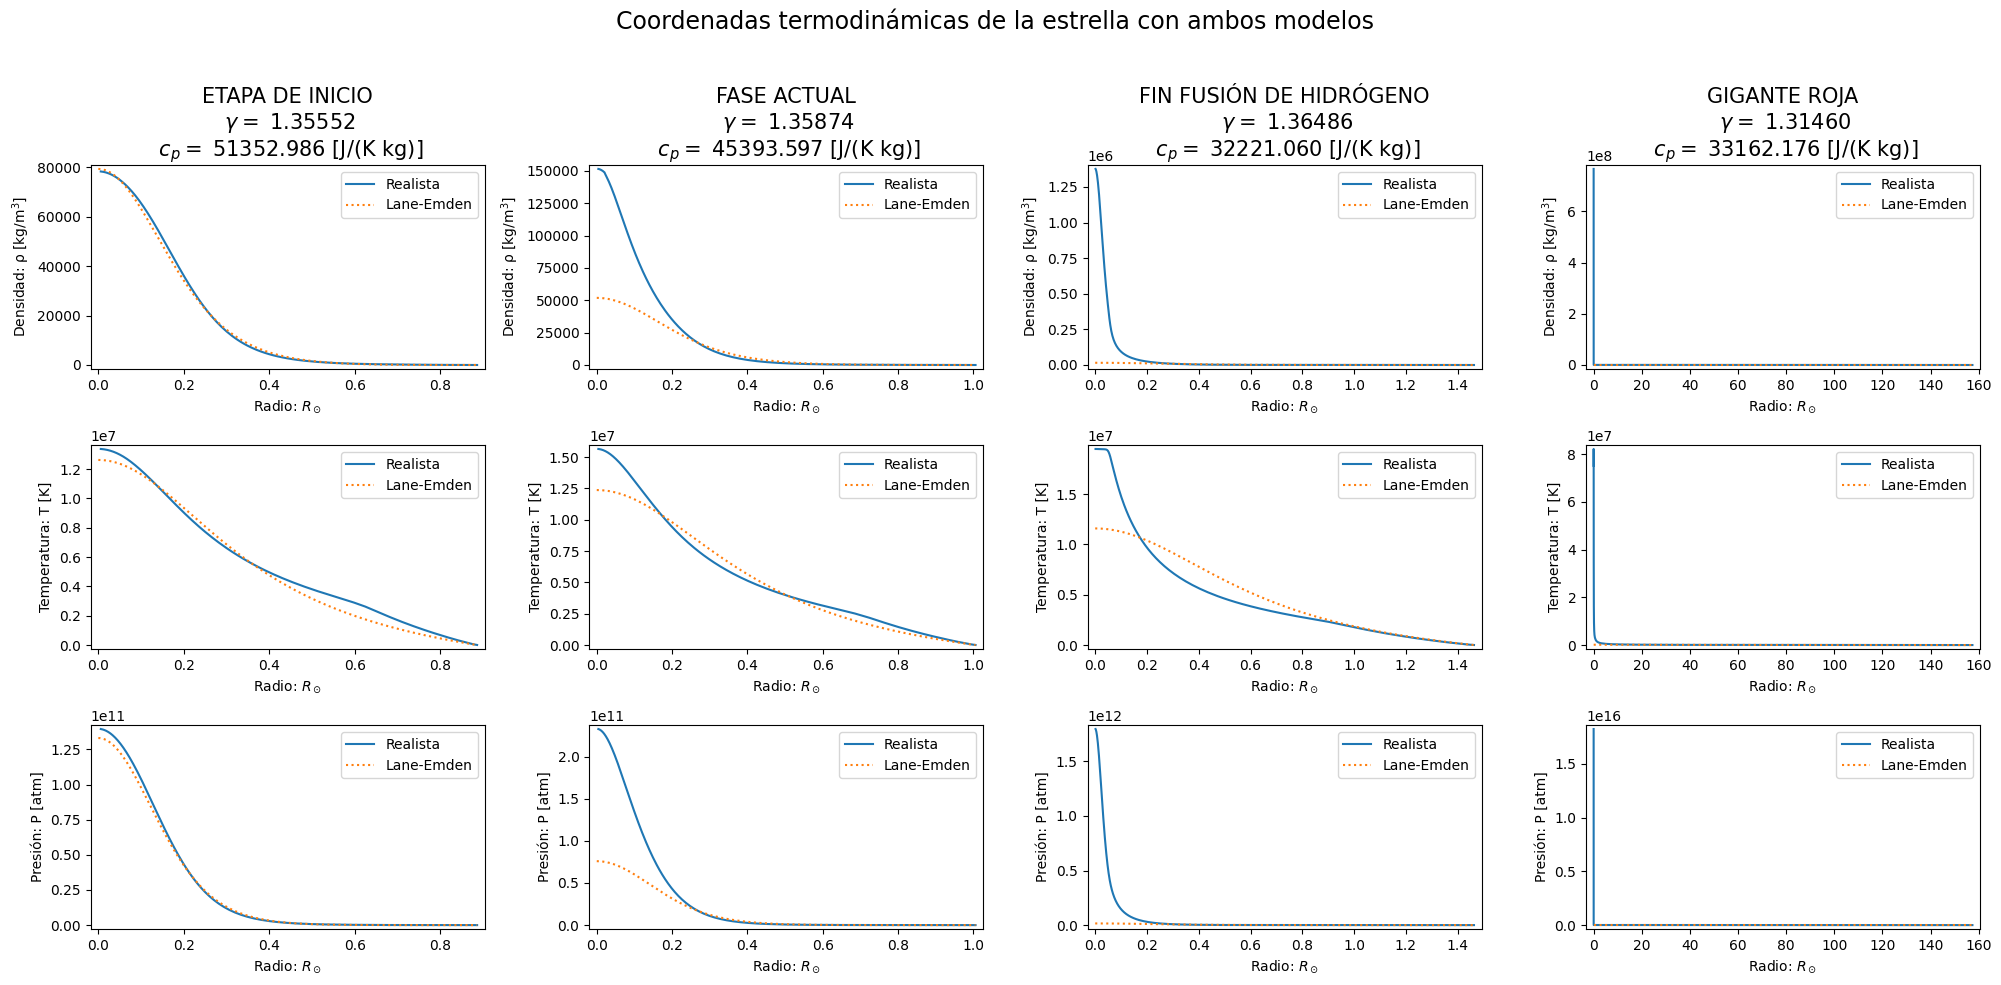

In [ ]:
fig, [axrho, axT, axP] = plt.subplots(3,4)
fig.suptitle('Coordenadas termodinámicas de la estrella con ambos modelos\n', fontsize=17)
fig.set_size_inches(20,10)

ets = ['ETAPA DE INICIO', 'FASE ACTUAL', 'FIN FUSIÓN DE HIDRÓGENO', 'GIGANTE ROJA']

for i in range(4):
  et = etapas[i]
  rhos_real = np.array(dfs[et].iloc[:,4])     # [kg/m^3] - Densidad
  Ts_real = np.array(dfs[et].iloc[:,5])       # [K] - Temperatura
  ps_real = np.array(dfs[et].iloc[:,3])       # [Pa] - Presión
  rs_real = np.array(dfs[et].iloc[:,1])       # [R☉] - Distancia radial

  rhos, Ts, ps, rs, gamma, cp = lane_emden_model(et)

  # Gráfico de densidad
  axrho[i].plot(rs_real, rhos_real, label='Realista')
  axrho[i].plot(rs/Rsun, rhos, ':', label='Lane-Emden')
  axrho[i].set_xlabel('Radio: $R_\odot$')
  axrho[i].set_ylabel('Densidad: ρ [kg/m$^3$]')
  axrho[i].legend()
  axrho[i].margins(0.02, 0.02)
  axrho[i].set_title(ets[i], fontsize=15)
  #
  text = ets[i] + '\n $\gamma=$ %.5lf \n $c_p=$ %.3lf [J/(K kg)]'%(gamma,cp)
  axrho[i].set_title(text, fontsize=15)

  # Gráfico de temperatura
  axT[i].plot(rs_real, Ts_real, label='Realista')
  axT[i].plot(rs/Rsun, Ts, ':', label='Lane-Emden')
  axT[i].set_xlabel('Radio: $R_\odot$')
  axT[i].set_ylabel('Temperatura: T [K]')
  axT[i].legend()
  axT[i].margins(0.02, 0.02)

  # Gráfico de presión
  axP[i].plot(rs_real, ps_real/101325, label='Realista')
  axP[i].plot(rs/Rsun, ps/101325, ':', label='Lane-Emden')
  axP[i].set_xlabel('Radio: $R_\odot$')
  axP[i].set_ylabel('Presión: P [atm]')
  axP[i].legend()
  axP[i].margins(0.02, 0.02)

fig.tight_layout()

### Punto 5

¿Cómo podría mejorarse el ajuste entre las propiedades calculadas con el modelo politrópico y el model realista? Intentelo al menos con el interior del Sol en una de las etapas estudiadas.

\
**Análisis:**

El siguiente modelo que se construyó para mejorar el ajuste entre el modelo de Lane-Emden y el realista consiste en determinar un valor del índice efectivo $\gamma$ para cada etapa tal que la diferencia entre las densidades centrales de cada modelo difieran en algún $\Delta \rho_c$, el cual puede escogerse de acuerdo al orden de magnitud de los datos.

El proceso que se sigue es partir de un valor inicial $\gamma_0$ e ir acumulando este valor en un $d \gamma$ hasta un límite definido como el promedio de los índices adiabáticos de la estrella. Esto se hace con el fin de determinar el índice efectivo que mejor aproxime estas densidades centrales.

\
**Escogencia del $\gamma_0$ y $d \gamma$:**

En clase fue visto que cuanto menor es el índice efectivo, más inclinada es la curva de densidad y presión. Incluso esto también puede deducirse de los gráficos del literal anterior. Nos apoyamos de este argumento para tener una buena escogencia del $\gamma_0$.

Así mismo, como el modelo de Lane-Emden es bastantes sensible al valor de $\gamma$, es decir, los resultados que devuelve para dos valores de $\gamma$ diferentes tienen una variación muy grande, es adecuado escoger un $d \gamma$ lo suficientemente pequeño para que tener mayor precisión en la aproximación.

In [ ]:
def LE_gamma(et, gamma0=6/5, dg=0.001, drho=3000):
  """ Propiedades de la estrella en la etapa 'et' """
  R = 10**df.log10R[et]*Rsun            # [m] - Radio
  g0 = G*df.M[et]*Msun/R**2             # [m/s^2] - Aceleración de la gravedad
  gammas = np.array(dfs[et].iloc[:,9])  # índice adiabático

  # Masa molecular de la estrella
  X = dfs[et].iloc[:,26]
  Y = dfs[et].iloc[:,29]
  Z = 1-X-Y
  Mmol = 4/(3+5*X-Z)*1e-3
  Mmol = Mmol.mean()        # [kg/mol] - Masa molar

  """ Modelo realista """
  rhos_real = np.array(dfs[et].iloc[:,4])

  """ Modelo de Lane-Emden """
  gamma = gamma0
  while gamma <= max(gammas):
    cp = gamma/(gamma-1)*consR/Mmol   # [J/(K kg)]
    T0 = g0*R/cp

    hasurf, xins, tetans, tetapns = politropa(gamma)

    # Límites de la polítropa (en la superficie)
    xi0 = xins[-1]           # ξ_0
    tetap0 = tetapns[-1]     # θ(ξ_0)

    Tc = -T0/(xi0*tetap0)
    lamb = R/xi0
    rhoc = cp*Tc/(4*np.pi*G*lamb**2)

    gamma += dg
    # Comparamos con las densidades en el centro en ambos modelos
    if( abs(rhoc - rhos_real[-1]) <= drho):
      break
  #
  rhos = rhoc*tetans**(1/(gamma-1))
  Ts = Tc*tetans
  ps = consR*rhos*Ts/Mmol   # [Pa] - Presión
  rs = xins*lamb

  return rhos, Ts, ps, rs, gamma, Mmol, xins[0]
# ==============================================================================

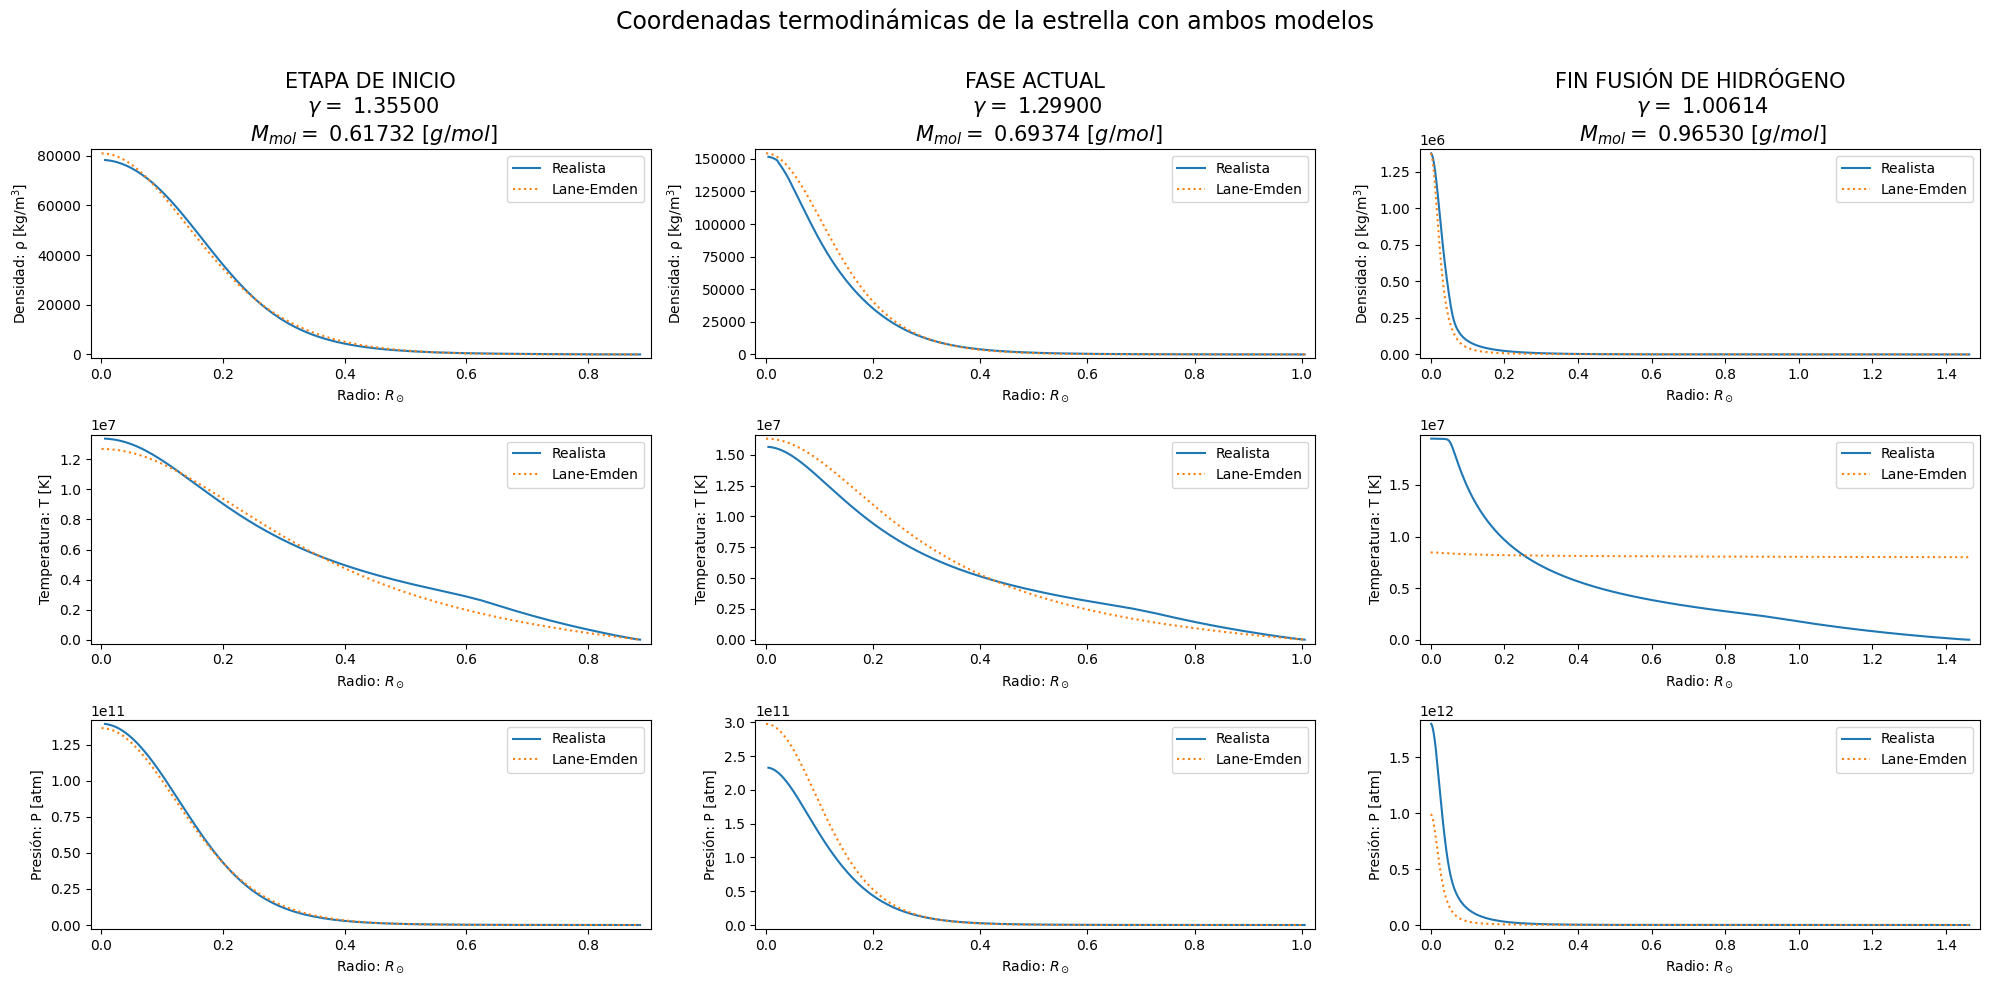

In [ ]:
fig, [axrho, axT, axP] = plt.subplots(3,3)
fig.suptitle('Coordenadas termodinámicas de la estrella con ambos modelos\n', fontsize=17)
fig.set_size_inches(20,10)

ets = ['ETAPA DE INICIO', 'FASE ACTUAL', 'FIN FUSIÓN DE HIDRÓGENO', 'GIGANTE ROJA']

for i in range(3):
  et = etapas[i]
  rhos_real = np.array(dfs[et].iloc[:,4])     # [kg/m^3] - Densidad
  Ts_real = np.array(dfs[et].iloc[:,5])       # [K] - Temperatura
  ps_real = np.array(dfs[et].iloc[:,3])       # [Pa] - Presión
  rs_real = np.array(dfs[et].iloc[:,1])       # [R☉] - Distancia radial

  rhos, Ts, ps, rs, gamma, Mmol, xins0 = LE_gamma(et)

  if i==2:
    rhos, Ts, ps, rs, gamma, Mmol, xins0 = LE_gamma(et, 1.00001, 0.00001)

  # Gráfico de densidad
  axrho[i].plot(rs_real, rhos_real, label='Realista')
  axrho[i].plot(rs/Rsun, rhos, ':', label='Lane-Emden')
  axrho[i].set_xlabel('Radio: $R_\odot$')
  axrho[i].set_ylabel('Densidad: ρ [kg/m$^3$]')
  axrho[i].legend()
  axrho[i].margins(0.02, 0.02)
  #
  text = ets[i] + '\n $\gamma=$ %.5lf \n $M_{mol}=$ %.5lf $ [g/mol]$'%(gamma,Mmol*1e3)
  axrho[i].set_title(text, fontsize=15)

  # Gráfico de temperatura
  axT[i].plot(rs_real, Ts_real, label='Realista')
  axT[i].plot(rs/Rsun, Ts, ':', label='Lane-Emden')
  axT[i].set_xlabel('Radio: $R_\odot$')
  axT[i].set_ylabel('Temperatura: T [K]')
  axT[i].legend()
  axT[i].margins(0.02, 0.02)

  # Gráfico de presión
  axP[i].plot(rs_real, ps_real/101325, label='Realista')
  axP[i].plot(rs/Rsun, ps/101325, ':', label='Lane-Emden')
  axP[i].set_xlabel('Radio: $R_\odot$')
  axP[i].set_ylabel('Presión: P [atm]')
  axP[i].legend()
  axP[i].margins(0.02, 0.02)

fig.tight_layout()

**Observaciones:**

* Notamos que el modelo reproduce bastante bien las coordenadas termodinámicas de la estrella en la etapa de edad cero en todo su interior hasta la superficie. Sin embargo, este no es el caso de la etapa "actual" donde el modelo reproduce bien la densidad y temperatura, pero la presión difiere mucho del modelo real en la zona central de la estrella. Esta diferencia se debe a la relación inversa que tiene la presión con la masa molar ($M_{mol}$).

  En la primera etapa, la composición molecular (hidrógeno y helio) de la estrella se distribuye de manera uniforme tanto en la región central como en la región externa, haciendo que la masa molar tenga un valor aproximadamente constante en cualquier lugar de la estrella. Pero esto no sucede en la etapa actual, en donde ya se ha fusionado gran cantidad de hidrógeno del núcleo y hay mayor composición de helio allí que en la zona exterior, en la cual hay mayor cantidad de hidrógeno. Esto hace que la masa molecular no se distribuya de manera más uniforme en cualquier sector de la estrella, por tanto, la masa molar en el interior difiere de la masa molar del exterior.

  El hecho de que la presión real sea menor a la modelada por Lane-Emden, el cual utiliza el promedio total de la masa molar, implica que la masa molar en el centro es mayor a ese promedio, y esto explica porqué las presiones tienen una notoría diferencia en la zona central de la estrella.

* En la tercera etapa, donde ya se ha fusionado todo el hidrógeno del núcleo de la estrella, podemos notar del gráfico que la densidad se reproduce bien, pero el resto de coordenadas termodinámicas presentan una mucho más notoría diferencia respecto al modelo realista, y esto es porque el argumento de la anterior observación tiene un mayor peso (la distribución de la masa molar no es uniforme), por tanto, utilizar el promedio de la masa molar ($M_{mol}$) previene la buena aproximación del modelo de Lane-Emden al modelo realista.

### Soluciones posibles para mejorar la aproximación:


* se puede interpolar los datos reales (199 datos) con los de Lane Emden (1000 datos) para comparar la densidad en cada punto tal que la diferencia entre ellas no sea muy grande